# Industrial Electricity Prices: History and AEO2026 Projections

This notebook combines historical EIA annual industrial electricity prices with the national industrial-price scenarios in AEO2026. Historical state prices are shown through the latest complete year. It also creates estimated state projections by applying each AEO2026 national scenario's percentage path to the latest observed state price.

> **Important:** AEO2026 does not provide state-level price forecasts. State projections produced here are scenario-based estimates derived from `ELEC`, not official EIA state forecasts. Because the historical series is reported in nominal cents/kWh while AEO2026 is in constant 2025 cents/kWh, projections use AEO's percentage changes and are anchored to the latest observed price.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)

In [ ]:
# Locate the project data whether this notebook is run from the project root or Script/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Data' / 'Electricity').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ELECTRICITY_PATH = PROJECT_ROOT / 'Data' / 'Electricity'
HISTORICAL_PATH = ELECTRICITY_PATH / 'ELEC.PRICE.A.csv'
AEO_PATH = ELECTRICITY_PATH / 'AEO2026' / 'AEO2026.PRCE.A.csv'

# Leading states from the data-center analysis in EDA ELEC.ipynb.
TOP_DC_STATES = ['VA', 'GA', 'TX', 'PA', 'WA', 'OH', 'NY', 'OR']
HISTORY_START_YEAR = 2010
REFERENCE_SCENARIO = 'CB2026'

print('Historical data:', HISTORICAL_PATH)
print('AEO2026 data:   ', AEO_PATH)

Historical data: /Users/annagrace/Desktop/School/Drexel/Summer 2026/DSCI591/Data/Electricity/ELEC.PRICE.A.csv
AEO2026 data:    /Users/annagrace/Desktop/School/Drexel/Summer 2026/DSCI591/Data/Electricity/AEO2026/AEO2026.PRCE.A.csv


## Projection approach

Each state's latest observed industrial price supplies its baseline. For every AEO2026 scenario, the national AEO price path is converted to an index beginning at 1.0; that index is then multiplied by the state's baseline. This preserves state price levels from `ELEC` while using AEO2026 only for projected growth or decline.

## Projected-state chart approach

Solid lines are observed `ELEC` prices. Dashed lines continue the same state colors using the AEO2026 reference-case percentage path.

## Prepare historical industrial prices

In [5]:
historical_wide = pd.read_csv(HISTORICAL_PATH).drop(columns=['Unnamed: 0'], errors='ignore')
historical_years = sorted(
    [column for column in historical_wide.columns if str(column).isdigit()],
    key=int,
)

historical_long = historical_wide.melt(
    id_vars=['series_id', 'name', 'geography', 'iso3166', 'sector', 'units'],
    value_vars=historical_years,
    var_name='year',
    value_name='price_cents_kwh',
)
historical_long['year'] = pd.to_numeric(historical_long['year'], errors='coerce').astype('Int64')
historical_long['price_cents_kwh'] = pd.to_numeric(
    historical_long['price_cents_kwh'], errors='coerce'
)
historical_long['state'] = historical_long['iso3166'].str.replace('USA-', '', regex=False)
historical_long.loc[historical_long['iso3166'].eq('USA'), 'state'] = 'US'

state_prices = (
    historical_long[historical_long['sector'].isin(['All', 'Commercial', 'Industrial', 'Residential'])]
    .groupby(['state', 'year', 'sector'], as_index=False)['price_cents_kwh']
    .mean()
)

industrial_history = state_prices.query(
    "sector == 'Industrial' and year >= @HISTORY_START_YEAR"
).dropna(subset=['price_cents_kwh'])

# Use the latest year with a complete value for the U.S. and every selected state.
required_geographies = TOP_DC_STATES + ['US']
complete_counts = (
    industrial_history[industrial_history['state'].isin(required_geographies)]
    .groupby('year')['state'].nunique()
)
eligible_years = complete_counts[
    complete_counts.eq(len(required_geographies))
    & (complete_counts.index < pd.Timestamp.today().year)
]
LATEST_FULL_YEAR = int(eligible_years.index.max())
industrial_history = industrial_history[industrial_history['year'].le(LATEST_FULL_YEAR)]

print(f'Historical period: {HISTORY_START_YEAR}–{LATEST_FULL_YEAR}')
print('States:', ', '.join(TOP_DC_STATES))
industrial_history.tail()

Historical period: 2010–2025
States: VA, GA, TX, PA, WA, OH, NY, OR


,state,year,sector,price_cents_kwh
5386,WY,2021,Industrial,6.83
5390,WY,2022,Industrial,6.89
5394,WY,2023,Industrial,7.06
5398,WY,2024,Industrial,7.96
5402,WY,2025,Industrial,8.66


## Select and reshape AEO2026 industrial-price scenarios

The filters below use the series meaning and units rather than relying only on a hard-coded series ID. A validation check requires one national industrial-price row per scenario.

In [6]:
aeo_wide = pd.read_csv(AEO_PATH)
aeo_years = sorted(
    [column for column in aeo_wide.columns if str(column).isdigit()],
    key=int,
)

national_industrial = aeo_wide[
    aeo_wide['units'].eq('2025 cents/kWh')
    & aeo_wide['name'].str.startswith(
        'Electricity : End-Use Prices : Industrial, United States', na=False
    )
].copy()

if national_industrial.empty:
    raise ValueError('No national AEO2026 industrial electricity-price series were found.')
if national_industrial['scenario_code'].duplicated().any():
    raise ValueError('Expected one national industrial-price series per AEO scenario.')

aeo_long = national_industrial.melt(
    id_vars=['series_id', 'scenario_code', 'scenario', 'units'],
    value_vars=aeo_years,
    var_name='year',
    value_name='aeo_price_2025_cents_kwh',
)
aeo_long['year'] = pd.to_numeric(aeo_long['year'], errors='coerce').astype('Int64')
aeo_long['aeo_price_2025_cents_kwh'] = pd.to_numeric(
    aeo_long['aeo_price_2025_cents_kwh'], errors='coerce'
)
aeo_long = aeo_long.dropna(subset=['aeo_price_2025_cents_kwh'])

print(f'AEO scenarios: {national_industrial["scenario_code"].nunique()}')
display(national_industrial[['scenario_code', 'scenario', 'units']].sort_values('scenario_code'))

AEO scenarios: 12


,scenario_code,scenario,units
843,AEO2025REF,AEO2025 Reference,2025 cents/kWh
3006,ALTELEC,Alternative Electricity,2025 cents/kWh
5169,ALTTRNP,Alternative Transportation,2025 cents/kWh
7332,CB2026,AEO2026 Reference,2025 cents/kWh
9495,ELECTRNP,Electric Power,2025 cents/kWh
11658,HIGHELDMD,High Electricity Demand,2025 cents/kWh
13821,HIGHOGS,High Oil and Gas Supply,2025 cents/kWh
15984,HIGHZTC,High Zero-Carbon Technology Cost,2025 cents/kWh
18147,HM2026,High Economic Growth,2025 cents/kWh
20310,LM2026,Low Economic Growth,2025 cents/kWh


## Rebase projections to the latest historical U.S. price

For each scenario, the first available AEO value at or after the historical endpoint is assigned the latest observed U.S. price. Later values follow the same percentage change as the original AEO series. The actual AEO values remain available in `aeo_price_2025_cents_kwh` for comparison.

In [7]:
us_last_price = industrial_history.loc[
    industrial_history['state'].eq('US'),
    ['year', 'price_cents_kwh'],
].sort_values('year').iloc[-1]

projection_rows = []
for scenario_code, scenario_df in aeo_long.groupby('scenario_code'):
    scenario_df = scenario_df[scenario_df['year'].ge(LATEST_FULL_YEAR)].sort_values('year').copy()
    if scenario_df.empty:
        continue
    baseline = scenario_df.iloc[0]['aeo_price_2025_cents_kwh']
    scenario_df['price_cents_kwh'] = (
        scenario_df['aeo_price_2025_cents_kwh'] / baseline * us_last_price['price_cents_kwh']
    )
    projection_rows.append(scenario_df)

projections = pd.concat(projection_rows, ignore_index=True)
projection_start = int(projections['year'].min())
projection_end = int(projections['year'].max())

print(f'Historical U.S. endpoint: {LATEST_FULL_YEAR} = {us_last_price["price_cents_kwh"]:.2f} cents/kWh')
print(f'Projection period: {projection_start}–{projection_end}')
projections.head()

Historical U.S. endpoint: 2025 = 8.62 cents/kWh
Projection period: 2025–2050


,series_id,scenario_code,scenario,units,year,aeo_price_2025_cents_kwh,price_cents_kwh
0,AEO.2026.AEO2025REF.PRCE_NA_IDAL_NA_ELC_NA_NA_Y13CNTPKWH.A,AEO2025REF,AEO2025 Reference,2025 cents/kWh,2025,9.064336,8.620000
1,AEO.2026.AEO2025REF.PRCE_NA_IDAL_NA_ELC_NA_NA_Y13CNTPKWH.A,AEO2025REF,AEO2025 Reference,2025 cents/kWh,2026,8.229500,7.826088
2,AEO.2026.AEO2025REF.PRCE_NA_IDAL_NA_ELC_NA_NA_Y13CNTPKWH.A,AEO2025REF,AEO2025 Reference,2025 cents/kWh,2027,7.723482,7.344875
3,AEO.2026.AEO2025REF.PRCE_NA_IDAL_NA_ELC_NA_NA_Y13CNTPKWH.A,AEO2025REF,AEO2025 Reference,2025 cents/kWh,2028,7.666985,7.291147
4,AEO.2026.AEO2025REF.PRCE_NA_IDAL_NA_ELC_NA_NA_Y13CNTPKWH.A,AEO2025REF,AEO2025 Reference,2025 cents/kWh,2029,7.785047,7.403422


## Create state projections from ELEC

Each state's latest observed `ELEC` industrial price supplies its baseline. Each AEO scenario is converted to an index beginning at 1.0 and multiplied by that state baseline. These are analytical estimates, not official EIA state forecasts.

In [8]:
state_baselines = (
    industrial_history[
        industrial_history['state'].isin(TOP_DC_STATES)
        & industrial_history['year'].eq(LATEST_FULL_YEAR)
    ][['state', 'price_cents_kwh']]
    .rename(columns={'price_cents_kwh': 'state_baseline_cents_kwh'})
)
scenario_factors = projections[
    ['scenario_code', 'scenario', 'year', 'aeo_price_2025_cents_kwh']
].copy()
scenario_factors['aeo_baseline'] = scenario_factors.groupby('scenario_code')[
    'aeo_price_2025_cents_kwh'
].transform('first')
scenario_factors['projection_factor'] = (
    scenario_factors['aeo_price_2025_cents_kwh'] / scenario_factors['aeo_baseline']
)
state_projections = state_baselines.merge(scenario_factors, how='cross')
state_projections['projected_price_cents_kwh'] = (
    state_projections['state_baseline_cents_kwh'] * state_projections['projection_factor']
)
state_projections = state_projections.sort_values(
    ['state', 'scenario_code', 'year']
).reset_index(drop=True)
projection_output = ELECTRICITY_PATH / 'AEO2026' / 'ELEC.industrial.state_projections.csv'
state_projections.to_csv(projection_output, index=False)
print(f'Created {len(state_projections):,} projections and saved them to {projection_output.name}')
state_projections.head()

Created 2,496 projections and saved them to ELEC.industrial.state_projections.csv


,state,state_baseline_cents_kwh,scenario_code,scenario,year,aeo_price_2025_cents_kwh,aeo_baseline,projection_factor,projected_price_cents_kwh
0,GA,7.81,AEO2025REF,AEO2025 Reference,2025,9.064336,9.064336,1.000000,7.810000
1,GA,7.81,AEO2025REF,AEO2025 Reference,2026,8.229500,9.064336,0.907899,7.090690
2,GA,7.81,AEO2025REF,AEO2025 Reference,2027,7.723482,9.064336,0.852074,6.654695
3,GA,7.81,AEO2025REF,AEO2025 Reference,2028,7.666985,9.064336,0.845841,6.606016
4,GA,7.81,AEO2025REF,AEO2025 Reference,2029,7.785047,9.064336,0.858866,6.707741


## ELEC history with projected state prices

Solid lines are observed `ELEC` prices. Dashed lines continue the same state colors using the AEO2026 reference-case percentage path.

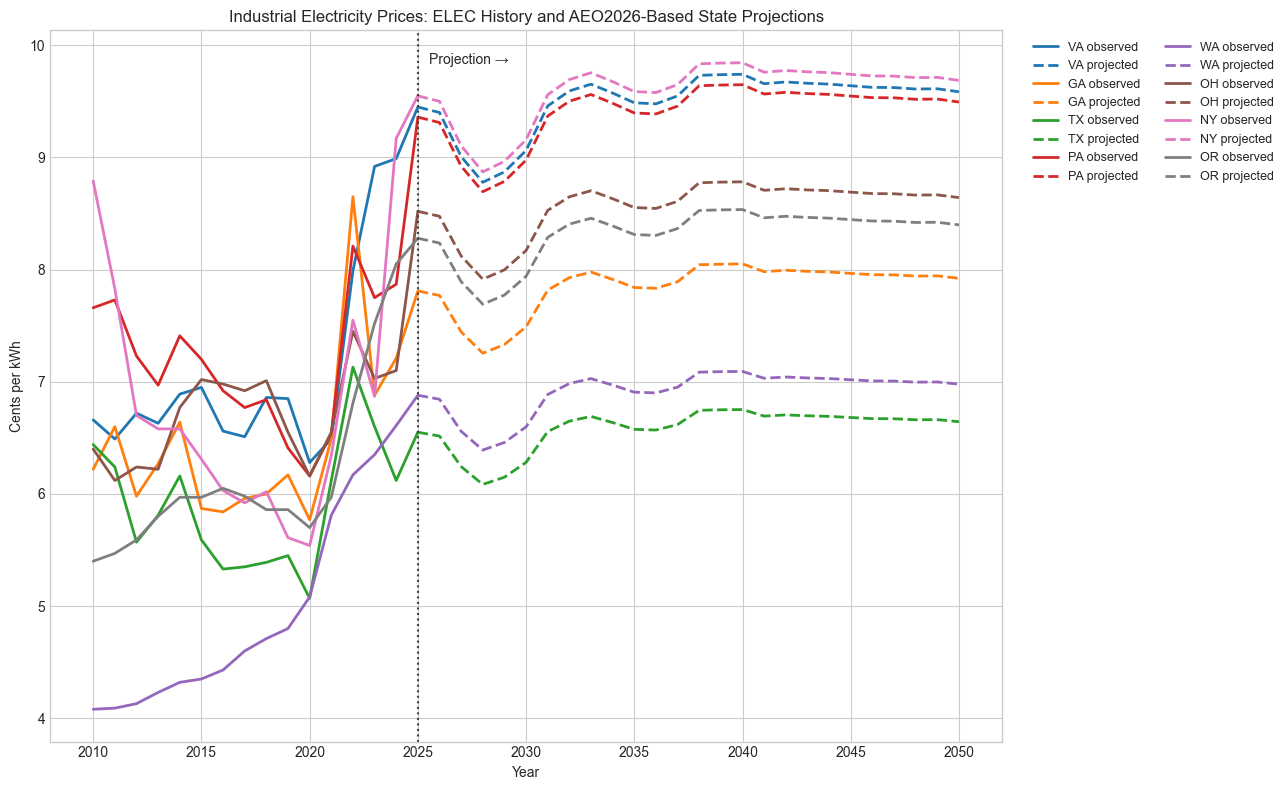

In [9]:
historical_states = industrial_history[
    industrial_history['state'].isin(TOP_DC_STATES)
].pivot(index='year', columns='state', values='price_cents_kwh')
reference_state_projections = state_projections[
    state_projections['scenario_code'].eq(REFERENCE_SCENARIO)
]
fig, ax = plt.subplots(figsize=(13, 8))
colors = dict(zip(TOP_DC_STATES, plt.cm.tab10.colors[:len(TOP_DC_STATES)]))
for state in TOP_DC_STATES:
    ax.plot(historical_states.index, historical_states[state], color=colors[state],
            linewidth=2, label=f'{state} observed')
    projected_state = reference_state_projections[
        reference_state_projections['state'].eq(state)
    ]
    ax.plot(projected_state['year'], projected_state['projected_price_cents_kwh'],
            color=colors[state], linewidth=2, linestyle='--', label=f'{state} projected')
ax.axvline(LATEST_FULL_YEAR, color='0.25', linestyle=':', linewidth=1.5)
ax.text(LATEST_FULL_YEAR + 0.5, ax.get_ylim()[1] * 0.98, 'Projection →', va='top')
ax.set_title('Industrial Electricity Prices: ELEC History and AEO2026-Based State Projections')
ax.set_xlabel('Year')
ax.set_ylabel('Cents per kWh')
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## Annual industrial price trends with AEO2026 scenarios

State history is plotted in light solid lines. The national historical series is black. The AEO2026 reference case is the dark dashed projection; the remaining AEO2026 cases form a labeled scenario envelope.

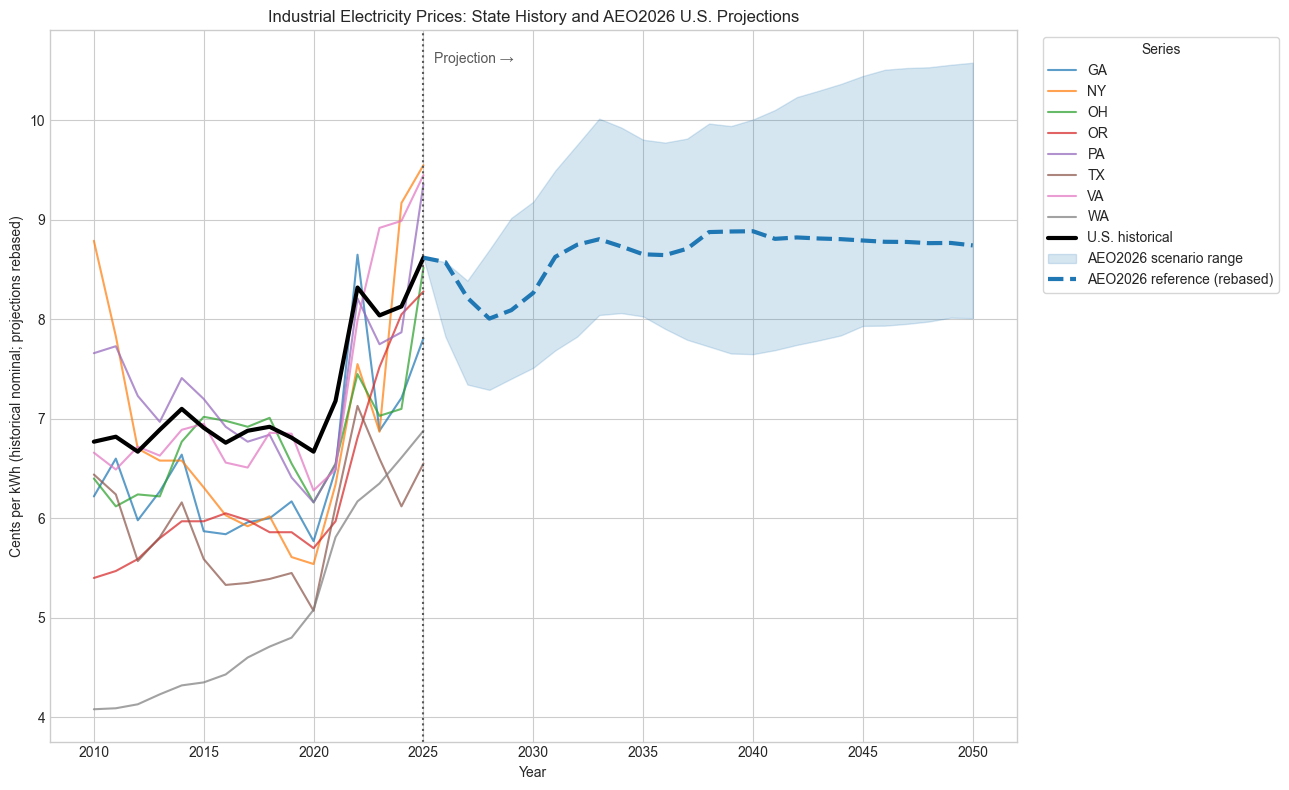

In [10]:
trend_price = industrial_history[
    industrial_history['state'].isin(TOP_DC_STATES)
    & industrial_history['year'].between(HISTORY_START_YEAR, LATEST_FULL_YEAR)
]
pivot_price = trend_price.pivot(index='year', columns='state', values='price_cents_kwh')
us_history = industrial_history[industrial_history['state'].eq('US')].sort_values('year')

scenario_band = projections.groupby('year')['price_cents_kwh'].agg(['min', 'max'])
reference_projection = projections[
    projections['scenario_code'].eq(REFERENCE_SCENARIO)
].sort_values('year')

fig, ax = plt.subplots(figsize=(13, 8))
pivot_price.plot(ax=ax, linewidth=1.5, alpha=0.72)
ax.plot(
    us_history['year'], us_history['price_cents_kwh'],
    color='black', linewidth=3, label='U.S. historical', zorder=5,
)
ax.fill_between(
    scenario_band.index.to_numpy(dtype=float),
    scenario_band['min'].to_numpy(dtype=float),
    scenario_band['max'].to_numpy(dtype=float),
    color='tab:blue', alpha=0.18, label='AEO2026 scenario range',
)
ax.plot(
    reference_projection['year'], reference_projection['price_cents_kwh'],
    color='tab:blue', linewidth=3, linestyle='--',
    label='AEO2026 reference (rebased)', zorder=6,
)
ax.axvline(LATEST_FULL_YEAR, color='0.35', linestyle=':', linewidth=1.5)
ax.text(
    LATEST_FULL_YEAR + 0.5, ax.get_ylim()[1] * 0.98, 'Projection →',
    color='0.35', va='top', fontsize=10,
)
ax.set_title('Industrial Electricity Prices: State History and AEO2026 U.S. Projections')
ax.set_xlabel('Year')
ax.set_ylabel('Cents per kWh (historical nominal; projections rebased)')
ax.legend(title='Series', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
fig.tight_layout()
plt.show()

## Optional detailed scenario chart

This second view labels every national AEO2026 scenario, which is useful when the scenario spread matters more than the state comparison.

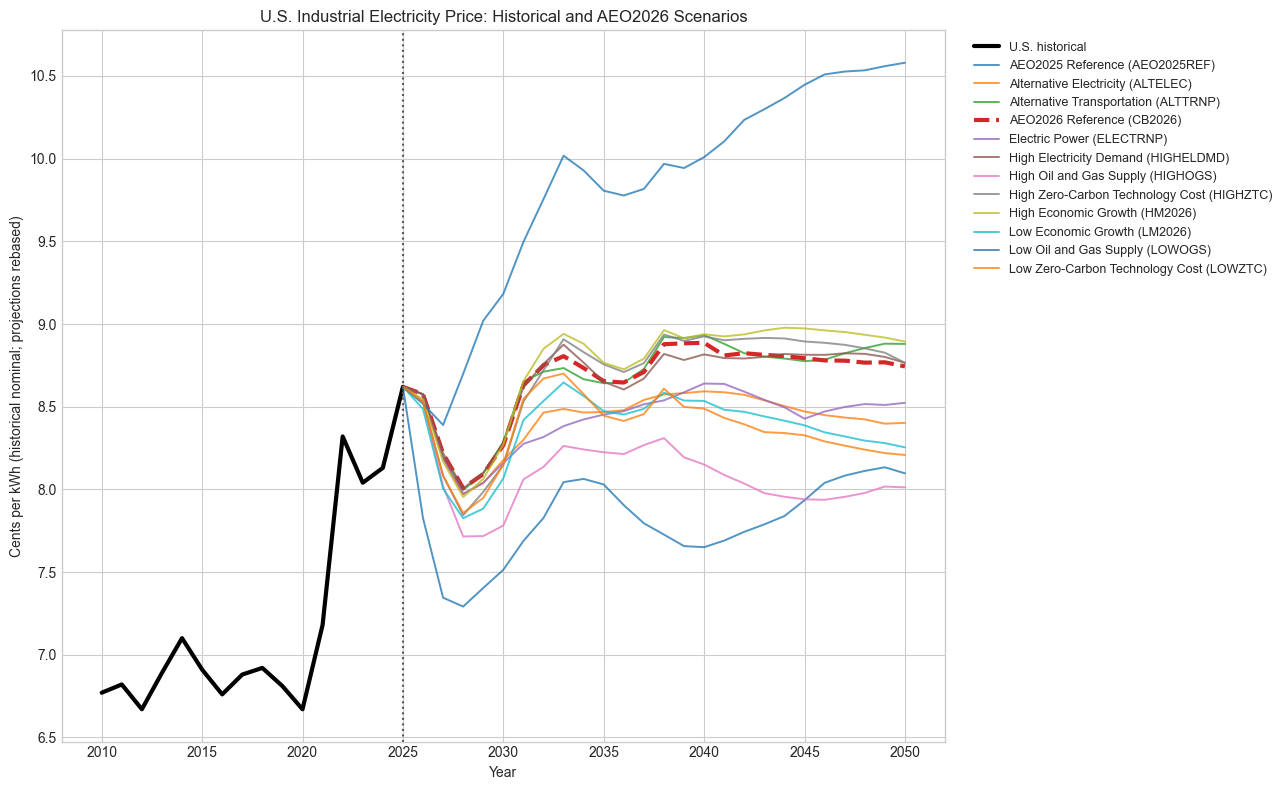

In [11]:
fig, ax = plt.subplots(figsize=(13, 8))
ax.plot(
    us_history['year'], us_history['price_cents_kwh'],
    color='black', linewidth=3, label='U.S. historical',
)

for scenario_code, scenario_df in projections.groupby('scenario_code'):
    label = scenario_df['scenario'].iloc[0]
    is_reference = scenario_code == REFERENCE_SCENARIO
    ax.plot(
        scenario_df['year'], scenario_df['price_cents_kwh'],
        linewidth=3 if is_reference else 1.4,
        linestyle='--' if is_reference else '-',
        alpha=1 if is_reference else 0.78,
        label=f'{label} ({scenario_code})',
    )

ax.axvline(LATEST_FULL_YEAR, color='0.35', linestyle=':', linewidth=1.5)
ax.set_title('U.S. Industrial Electricity Price: Historical and AEO2026 Scenarios')
ax.set_xlabel('Year')
ax.set_ylabel('Cents per kWh (historical nominal; projections rebased)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()